In [54]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/../irc_gym')

from irc.manager import IRCManager
from auditoryforage.utils import plot_AF_episode

# Train one agent for a single environment

In [55]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

No checkpoint loaded.
Initializing an agent with internal environment parameter:
(-3.0, 12.0, 15, 10, -8, -4)
Agent evaluated for 12 episodes of length 20. Average return -347.88. (0m00.11s)

Epoch:  1/50
Agent trained by 256 time steps (0m02.14s).

Epoch:  2/50
Agent trained by 256 time steps (0m02.27s).
Agent evaluated for 12 episodes of length 20. Average return -327.85. (0m00.10s)

Epoch:  3/50
Agent trained by 256 time steps (0m02.20s).

Epoch:  4/50
Agent trained by 256 time steps (0m02.25s).
Agent evaluated for 12 episodes of length 20. Average return -307.75. (0m00.10s)

Epoch:  5/50
Agent trained by 256 time steps (0m02.29s).

Epoch:  6/50
Agent trained by 256 time steps (0m02.09s).
Agent evaluated for 12 episodes of length 20. Average return -304.11. (0m00.10s)

Epoch:  7/50
Agent trained by 256 time steps (0m02.23s).

Epoch:  8/50
Agent trained by 256 time steps (0m02.35s).
Agent evaluated for 12 episodes of length 20. Average return -296.68. (0m00.11s)

Epoch:  9/50
Agent t

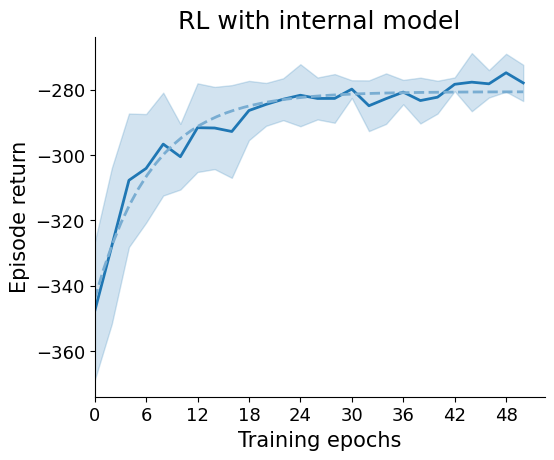

In [56]:
env_param = [-3.0, 12.0, 15, 10, -8, -4]
num_epochs = 50

# Lokesh - Changed to Zhe's version
seed = 100

# Lokesh - Changed to Zhe's version
# agent = manager.train_agent(env_param, num_epochs=num_epochs)
agent = manager.train_agent(env_param, num_epochs=num_epochs, seed = seed)

# Lokesh - Changed to Zhe's version
# agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))
agent, fig = manager.inspect_agent(env_param, seed = seed)

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

{'experiment': {'prob_01': 0.5,
  'no_signal_nodes': 4,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 1},
 'agent': {'lick_cost': -3.0,
  'food_reward': 12.0,
  'attention_cost_coeff': 15,
  'attention_cost_temp': 10,
  'penalty_cost': -8,
  'iti_cost': -4,
  'no_attention_modes': 3}}

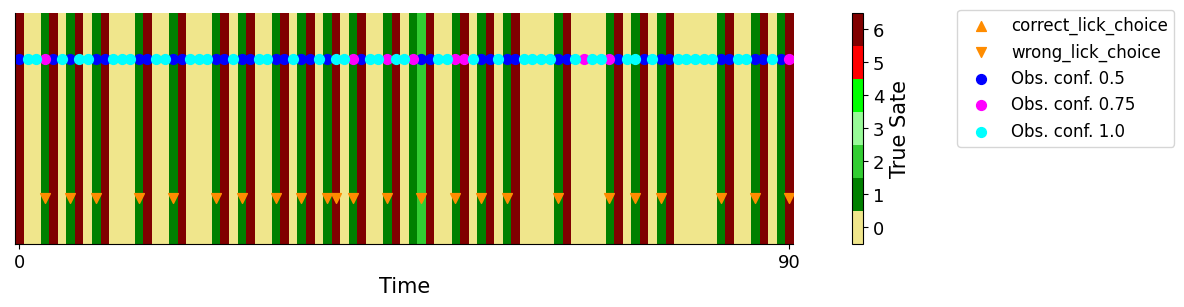

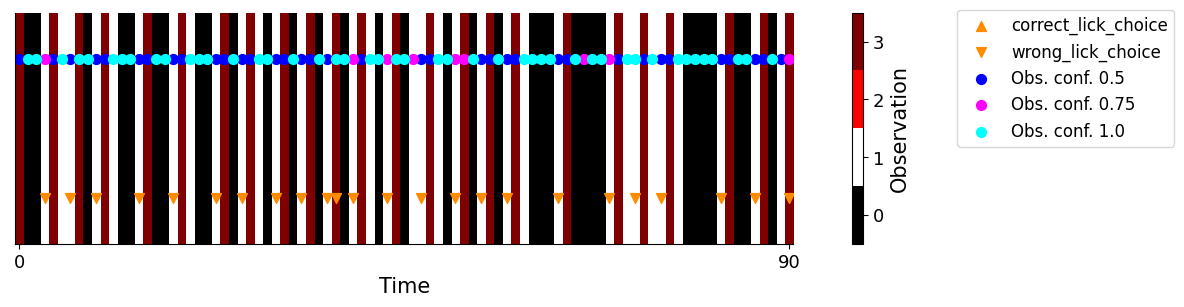

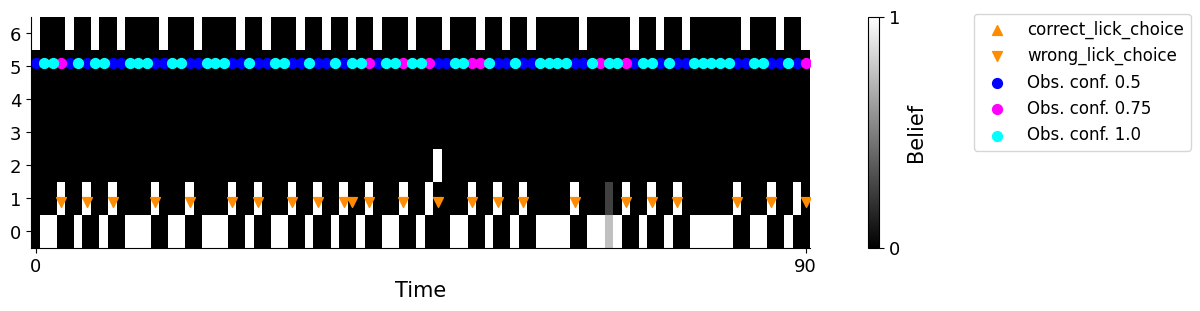

In [57]:
from auditoryforage.AF_env import AuditoryForaging

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'experiment': {'prob_01': 0.5},'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})

# Lokesh - Changed to Zhe's version
# episode = agent.run_one_episode(env=env, num_steps=60, q_states = [[i] for i in range(env.no_nodes)])
episode = agent.run_one_episode(env=env, num_steps=90, q_states = [[i] for i in range(env.no_nodes)])


fig = plot_AF_episode(episode, env)

env.spec



We can save the episode data in an external `pickle` file.

In [58]:
import os, pickle

episode_path = f'store/episode_{env.get_param()}.pickle'

if os.path.exists(episode_path):
    print(f"File {episode_path} already exists, will not be overwritten.")
else:
    with open(episode_path, 'wb') as f:
        pickle.dump({
            'external_env_param': env.get_param(),
            'internal_env_param': agent.model.env.get_param(),
            **episode,
        }, f)
    print(f"Episode data saved at '{episode_path}'.")

Episode data saved at 'store/episode_(-3.0, 12.0, 15, 10, -8, -4).pickle'.


# Train multiple agents for different environments

## Sweep over parameter grid

We define a grid of environment parameters, and train multiple agents for each of the combination using different random seeds.

The following can also be done by running `demo-sweep.py` in command line:
```bash
python demo-sweep.py env_param_grid=param_grids/param_grid_0.yaml num_epochs=20 count=5
```

In [59]:
env_param_grid = [
    [-3.0], # lick_cost
    [12.0], # food_reward
    [13, 14, 15, 16, 17], # attention_cost_coeff
    [8, 9, 10, 11, 12], # attention_cost_temp
    [-8],
    [-4]
]

# Lokesh - Changed to Zhe's version
agent_seeds = list(range(10))

num_epochs = 50 # number of RL epochs


# Lokesh - Changed to Zhe's version
# #Lokesh removed the agent_seeds, and count arguments (that can be specified).
# manager.train_agents(env_param_grid=env_param_grid, num_epochs=num_epochs)
manager.train_agents(env_param_grid=env_param_grid, num_epochs=num_epochs, seeds = agent_seeds)

0 works processed.
All works are processed or being processed.


In [60]:
# Lokesh - Changed to Zhe's version
# report = manager.overview_agents(env_param_grid=env_param_grid)
report = manager.overview_agents(env_param_grid=env_param_grid, seeds=agent_seeds, min_epoch=30)

Average progress of training 100.0% (30 epochs as complete).
Approximate training time 0m02.02s per epoch.
Approximate evaluation time 0m00.10s.
Average training optimality 99.9%


# Compute likelihood of an episode

## Likelihood of a specific agent

Given a sequence actions and observations, we compute the likelihood of episode data conditioned on a trained agent $p(a_{1:t}, o_{1:t}|\theta_\mathrm{agent})$.

In [61]:
logp = agent.episode_likelihood(episode['actions'], episode['observations'])
print('log likelihood {:.3f}'.format(logp))

log likelihood -45.592


## Likelihood of a series of agents

After multiple agents have been trained on a grid of environment parameters, compute the likelihood of episode data conditioned on each agent.

In [62]:
from irc.utils import logmeanexp

# Uncomment below line, and comment the one after that, if you want to speciy some other episode data
# 'episode_(-3.0, 12.0, 15, 10, -8, -4).pickle'
episode_path = f'episode_{env.get_param()}.pickle'

env_param_grid = [
    [-3.0], # lick_cost
    [12.0], # food_reward
    [13, 14, 15, 16, 17], # attention_cost_coeff
    [8, 9, 10, 11, 12], # attention_cost_temp
    [-8],
    [-4]
]

# Lokesh - Changed to Zhe's version
# logps = manager.compute_logps(episode_path=episode_path, env_param_grid=env_param_grid, min_epoch=5, min_optimality=.9)
logps = manager.compute_logps(
        episode_path=episode_path, env_param_grid=env_param_grid,
        agent_seeds=agent_seeds, min_epoch=25, min_optimality=0.98, patience=0,
    )

# logps = logmeanexp(logps, axis=(-2, -1))
# print(f"Log likelihood of all environments saved in an array of shape {logps.shape}")

p = np.exp(logmeanexp(logps, axis=(-2, -1)))
p /= np.nansum(p)

print(f"Probabilities of all environments saved in an array of shape {p.shape}")

Episode data saved at key C57150.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
250 valid agents found.
Computing likelihood of episode C57150 (90 time steps)...
------------
Processing 7147E44B (1)...
No checkpoint loaded.
Agent environment parameter:
(-3.0, 12.0, 16, 11, -8, -4)
Log likelihood of an agent (trained for 50 epochs): -114.657 ( 0m00.03s)
------------
Processing DE676D8F (11)...
No checkpoint loaded.
Agent environment parameter:
(-3.0, 12.0, 14, 10, -8, -4)
Log likelihood of an agent (trained for 50 epochs): -50.798 ( 0m00.04s)
------------
Processing FB248059 (21)...
No checkpoint loaded.
Agent environment parameter:
(-3.0, 12.0, 13, 9, -8, -4)
Log likelihood of an agent (trained for 50 epochs): -50.352 ( 0m00.03s)
------------
Processing 6701E7B7 (31)...
No checkpoint loaded.
Agent environment parameter:
(-3.0, 12.0, 15, 9, -8, -4)
Log likelihood of an agent (trained for 50 epochs): -205.481 ( 0m00.03s)
------------
Processing A6F4DB0A (41)...
No check

In [63]:
# Original Zhe's code
# from irc.utils import logmeanexp

# # for episode_path in ['episode_{:02d}.pickle'.format(i) for i in range(4, 12)]:
# for episode_path in ['episode_00.pickle']:
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     print('External environment parameter: {}'.format(tuple(saved['external_env_param'])))
#     print('Length of episode: {}'.format(saved['num_steps']))
    
#     logps = manager.compute_logps(
#         episode_path=episode_path, env_param_grid=env_param_grid,
#         agent_seeds=agent_seeds, min_epoch=25, min_optimality=0.98, patience=0,
#     )

#     p = np.exp(logmeanexp(logps, axis=(-2, -1)))
#     p /= np.nansum(p)

#     _, axes = plt.subplots(1, p.shape[2], figsize=(8, 2.5), gridspec_kw={'wspace': 0.02})
#     for i, ax in enumerate(axes):
#         h = ax.imshow(p[..., i], vmin=0, vmax=np.nanmax(p))
#         ax.set_title(r'$r_\mathrm{food}$'+'={:g}'.format(env_param_grid[2][i]))
#         ax.set_xticks(range(p.shape[1]))
#         ax.set_xticklabels(['{:g}'.format(v) for v in env_param_grid[1]])
#         ax.set_xlabel(r'$p_\mathrm{cue}$')
#         ax.set_yticks(range(p.shape[0]))
#         if i==0:
#             ax.set_yticklabels(['{:g}'.format(v) for v in env_param_grid[0]])
#             ax.set_ylabel(r'$p_\mathrm{appear}$')
#         else:
#             ax.set_yticklabels([])
#     # agent environment parameter
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     env_param = saved['internal_env_param']
#     i = env_param_grid[0].index(env_param[0])
#     j = env_param_grid[1].index(env_param[1])
#     k = env_param_grid[2].index(env_param[2])
#     axes[k].scatter(j, i, s=30, marker='o', color='tomato')
#     env_param = saved['external_env_param']
#     i = env_param_grid[0].index(env_param[0])
#     j = env_param_grid[1].index(env_param[1])
#     k = env_param_grid[2].index(env_param[2])
#     axes[k].scatter(j, i, s=40, marker='s', edgecolor='orchid', facecolor='none', linewidth=2)
#     plt.colorbar(h, ax=axes, label=r'$p(\theta|a_{1:t},o_{1:t})$', fraction=0.1)
#     plt.show()

In [64]:
# Modified for Lokesh's 3D case
# from irc.utils import logmeanexp

# # for episode_path in ['episode_{:02d}.pickle'.format(i) for i in range(4, 12)]:
# for episode_path in ['episode_(-3.0, 12.0, 15, 10, -8, -4).pickle','episode_(-3.0, 8.0, 19, 12, -8, -4).pickle', 'episode_(-3.0, 16.0, 13, 8, -8, -4).pickle']:
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     print('External environment parameter: {}'.format(tuple(saved['external_env_param'])))
#     print('Length of episode: {}'.format(saved['num_steps']))
    
#     #Lokesh removed the agent_seeds argument (that can be specified).
#     logps = manager.compute_logps(
#         episode_path=episode_path, env_param_grid=env_param_grid,
#         min_epoch=25, min_optimality=0.98, patience=0,
#     )

#     p = np.exp(logmeanexp(logps, axis=(-2, -1)))

#     #Lokesh added this in order to squeeze out unwanted dimensions
#     p = np.squeeze(p)

#     p /= np.nansum(p)

#     _, axes = plt.subplots(1, p.shape[0], figsize=(16, 5), gridspec_kw={'wspace': 0.02})
#     for i, ax in enumerate(axes):
#         h = ax.imshow(p[i,...], vmin=0, vmax=np.nanmax(p))
#         ax.set_title(r'$\mathrm{food reward}$'+'={:g}'.format(env_param_grid[1][i]))
#         ax.set_xticks(range(p.shape[2]))
#         ax.set_xticklabels(['{:g}'.format(v) for v in env_param_grid[3]])
#         ax.set_xlabel(r'$\mathrm{attention cost temp}$')
#         ax.set_yticks(range(p.shape[1]))
#         if i==0:
#             ax.set_yticklabels(['{:g}'.format(v) for v in env_param_grid[2]])
#             ax.set_ylabel(r'$\mathrm{attention cost coeff}$')
#         else:
#             ax.set_yticklabels([])
#     # agent environment parameter
#     with open(f'store/{episode_path}', 'rb') as f:
#         saved = pickle.load(f)
#     env_param = saved['internal_env_param']
#     i = env_param_grid[1].index(env_param[1])
#     j = env_param_grid[2].index(env_param[2])
#     k = env_param_grid[3].index(env_param[3])
#     axes[i].scatter(k, j, s=30, marker='o', color='tomato')
#     env_param = saved['external_env_param']
#     i = env_param_grid[1].index(env_param[1])
#     j = env_param_grid[2].index(env_param[2])
#     k = env_param_grid[3].index(env_param[3])
#     axes[i].scatter(k, j, s=40, marker='s', edgecolor='orchid', facecolor='none', linewidth=2)
#     plt.colorbar(h, ax=axes, label=r'$p(\theta|a_{1:t},o_{1:t})$', fraction=0.1)
#     plt.show()

External environment parameter: (-3.0, 12.0, 15, 10, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode C57150 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


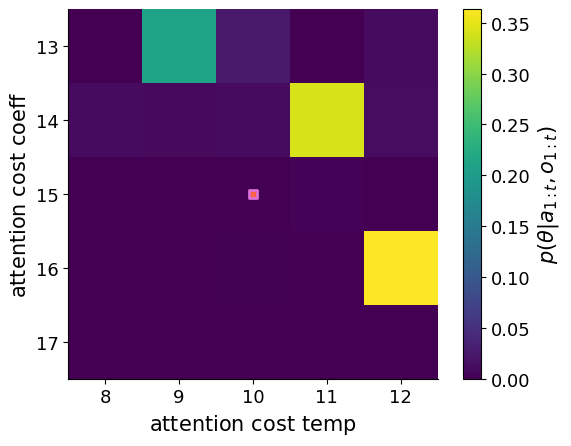

External environment parameter: (-3.0, 12.0, 14, 11, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode 2FCB34 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


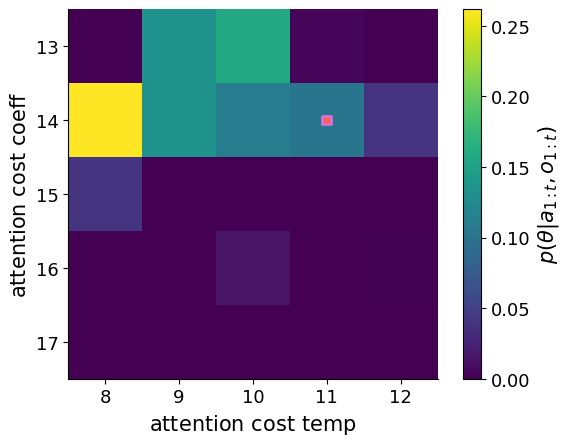

External environment parameter: (-3.0, 12.0, 13, 12, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode 928297 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


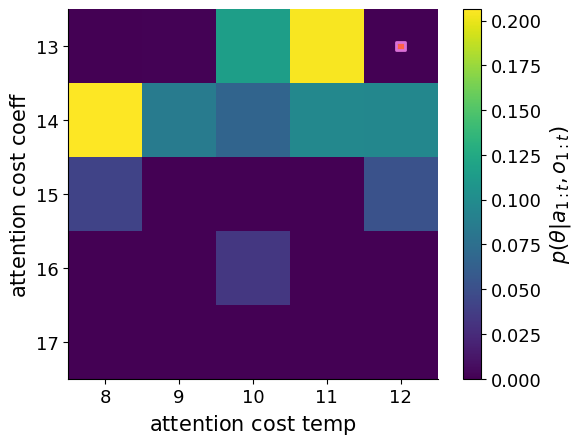

External environment parameter: (-3.0, 12.0, 16, 9, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode C29C7D (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


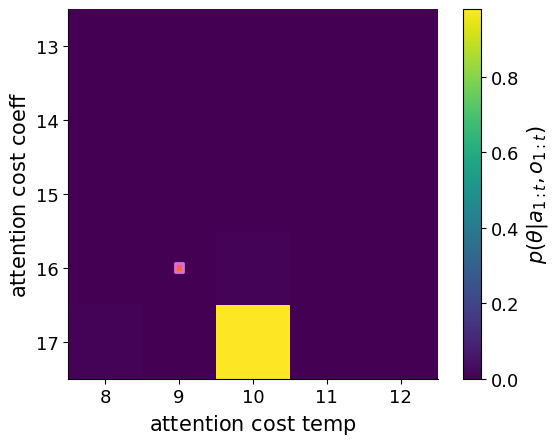

In [65]:
# Modified for Lokesh's 2D case
from irc.utils import logmeanexp

# for episode_path in ['episode_{:02d}.pickle'.format(i) for i in range(4, 12)]:
for episode_path in ['episode_(-3.0, 12.0, 15, 10, -8, -4).pickle','episode_(-3.0, 12.0, 14, 11, -8, -4).pickle', 'episode_(-3.0, 12.0, 13, 12, -8, -4).pickle','episode_(-3.0, 12.0, 16, 9, -8, -4).pickle']:
    with open(f'store/{episode_path}', 'rb') as f:
        saved = pickle.load(f)
    print('External environment parameter: {}'.format(tuple(saved['external_env_param'])))
    print('Length of episode: {}'.format(saved['num_steps']))
    
    #Lokesh removed the agent_seeds argument (that can be specified).
    logps = manager.compute_logps(
        episode_path=episode_path, env_param_grid=env_param_grid,
        min_epoch=25, min_optimality=0.98, patience=0,
    )

    p = np.exp(logmeanexp(logps, axis=(-2, -1)))

    #Lokesh added this in order to squeeze out unwanted dimensions
    p = np.squeeze(p)

    p /= np.nansum(p)


    h = plt.imshow(p, vmin=0, vmax=np.nanmax(p))
    plt.xticks(range(p.shape[1]), ['{:g}'.format(v) for v in env_param_grid[3]])
    plt.xlabel(r'$\mathrm{attention\ cost\ temp}$')
    plt.yticks(range(p.shape[0]), ['{:g}'.format(v) for v in env_param_grid[2]])
    plt.ylabel(r'$\mathrm{attention\ cost\ coeff}$')
    # agent environment parameter
    with open(f'store/{episode_path}', 'rb') as f:
        saved = pickle.load(f)
    env_param = saved['internal_env_param']
    i = env_param_grid[2].index(env_param[2])
    j = env_param_grid[3].index(env_param[3])
    plt.scatter(j, i, s=30, marker='o', color='tomato')
    env_param = saved['external_env_param']
    i = env_param_grid[2].index(env_param[2])
    j = env_param_grid[3].index(env_param[3])
    plt.scatter(j, i, s=40, marker='s', edgecolor='orchid', facecolor='none', linewidth=2)
    plt.colorbar(h, label=r'$p(\theta|a_{1:t},o_{1:t})$', fraction=0.1)
    plt.show()

External environment parameter: (-3.0, 12.0, 15, 10, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode C57150 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


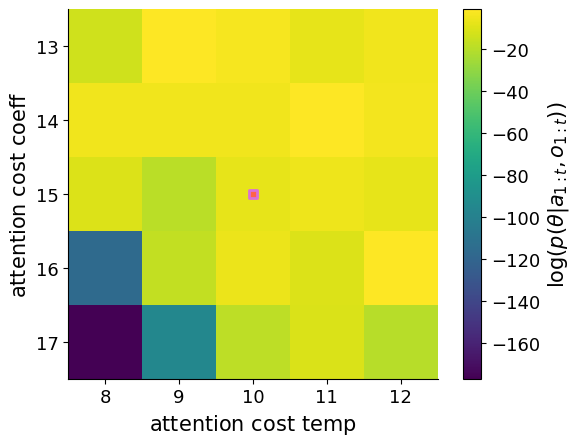

External environment parameter: (-3.0, 12.0, 14, 11, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode 2FCB34 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


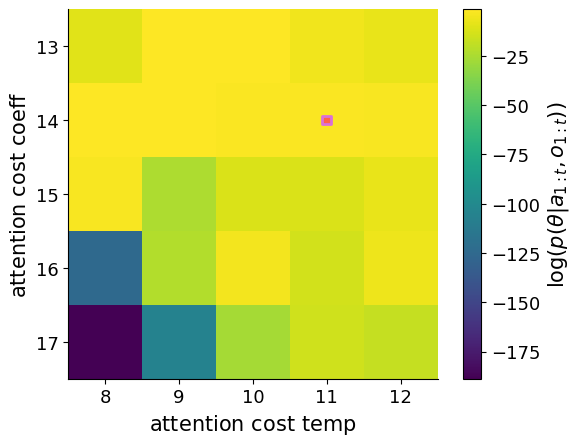

External environment parameter: (-3.0, 12.0, 13, 12, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode 928297 (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


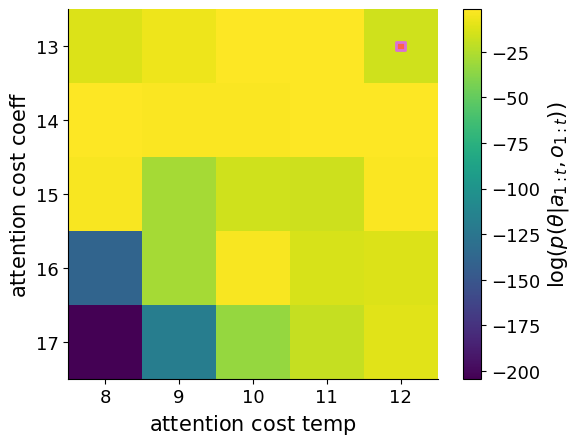

External environment parameter: (-3.0, 12.0, 16, 9, -8, -4)
Length of episode: 90
Use default agent seeds [0, 1, 2] for each environment parameter.
Use default belief seeds [0, 1, 2, 3, 4, 5, 6, 7] for each run.
75 valid agents found.
Computing likelihood of episode C29C7D (90 time steps)...
0 works processed.
All works are processed or being processed.
100.00% of the likelihood entries have been computed.


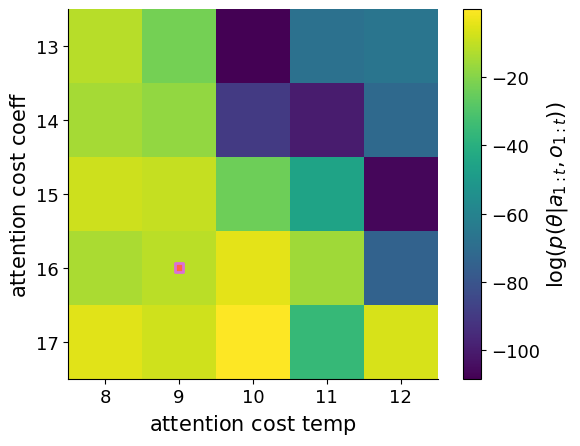

In [66]:
# Modified for Lokesh's 2D case
from irc.utils import logmeanexp

# for episode_path in ['episode_{:02d}.pickle'.format(i) for i in range(4, 12)]:
for episode_path in ['episode_(-3.0, 12.0, 15, 10, -8, -4).pickle','episode_(-3.0, 12.0, 14, 11, -8, -4).pickle', 'episode_(-3.0, 12.0, 13, 12, -8, -4).pickle','episode_(-3.0, 12.0, 16, 9, -8, -4).pickle']:
    with open(f'store/{episode_path}', 'rb') as f:
        saved = pickle.load(f)
    print('External environment parameter: {}'.format(tuple(saved['external_env_param'])))
    print('Length of episode: {}'.format(saved['num_steps']))
    
    #Lokesh removed the agent_seeds argument (that can be specified).
    logps = manager.compute_logps(
        episode_path=episode_path, env_param_grid=env_param_grid,
        min_epoch=25, min_optimality=0.98, patience=0,
    )

    p = np.exp(logmeanexp(logps, axis=(-2, -1)))

    #Lokesh added this in order to squeeze out unwanted dimensions
    p = np.squeeze(p)

    p /= np.nansum(p)


    # h = plt.imshow(p, vmin=0, vmax=np.nanmax(p))
    h = plt.imshow(np.log(p))

    plt.xticks(range(p.shape[1]), ['{:g}'.format(v) for v in env_param_grid[3]])
    plt.xlabel(r'$\mathrm{attention\ cost\ temp}$')
    plt.yticks(range(p.shape[0]), ['{:g}'.format(v) for v in env_param_grid[2]])
    plt.ylabel(r'$\mathrm{attention\ cost\ coeff}$')
    # agent environment parameter
    with open(f'store/{episode_path}', 'rb') as f:
        saved = pickle.load(f)
    env_param = saved['internal_env_param']
    i = env_param_grid[2].index(env_param[2])
    j = env_param_grid[3].index(env_param[3])
    plt.scatter(j, i, s=30, marker='o', color='tomato')
    env_param = saved['external_env_param']
    i = env_param_grid[2].index(env_param[2])
    j = env_param_grid[3].index(env_param[3])
    plt.scatter(j, i, s=40, marker='s', edgecolor='orchid', facecolor='none', linewidth=2)
    plt.colorbar(h, label=r'$\log(p(\theta|a_{1:t},o_{1:t}))$', fraction=0.1)
    plt.show()